In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.cluster import KMeans
from sklearn.utils import shuffle
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, accuracy_score, precision_recall_curve,roc_curve, f1_score

import pennylane as qml
from pennylane.templates import RandomLayers
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.optimizers import Adam
from keras import metrics
from qiskit.quantum_info import SparsePauliOp
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import GridSearchCV

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


import medmnist
from medmnist import INFO, Evaluator

print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

2024-07-03 10:43:57.517994: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-07-03 10:43:58.268852: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Num GPUs Available:  8


# Cardio Data

## Load Data Set:

In [2]:
df = pd.read_csv('2groups_globals.csv') # load data
df_mca = shuffle(df) # shuffle the data
df_mca = df_mca.drop(['Codi'],axis=1)

# Separate X and labels:
X = df_mca.iloc[:,:-1]
y = df_mca.iloc[:,-1].values.ravel()

In [3]:
y

array([1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0])

In [4]:
X.columns

Index(['FEVI', 'Strain_radial', 'Strain_circumf', 'Strain_long',
       'Syst_SR_radial', 'Syst_SR_circumf', 'Syst_SR_long', 'Diast_SR_radial',
       'Diast_SR_circumf', 'Diast_SR_long', 'Displacement_radial',
       'Displacement_circumf', 'Displacement_long', 'Syst_vel_radial',
       'Syst_vel_circumf', 'Syst_vel_long', 'Diast_vel_radial',
       'Diast_vel_circumf', 'Diast_vel_long'],
      dtype='object')

## Feature Selection:

### Pearson:

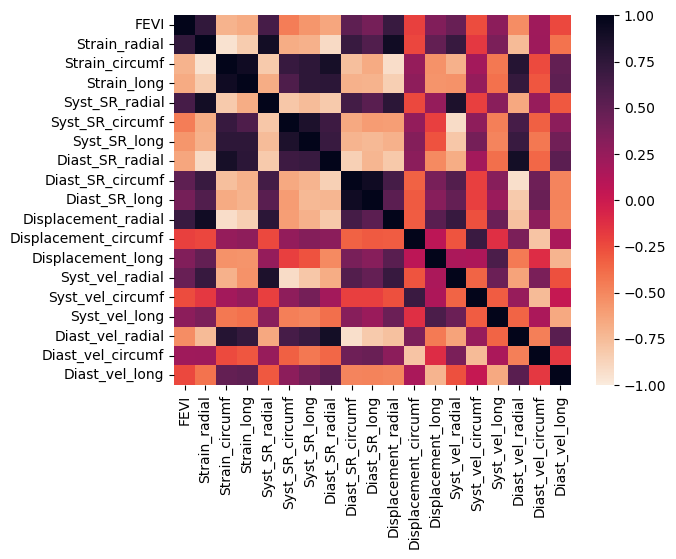

In [5]:
import scipy.stats as stats

sns.heatmap(X.corr(), vmin=-1, vmax=1,
annot=False,cmap="rocket_r")
plt.show()

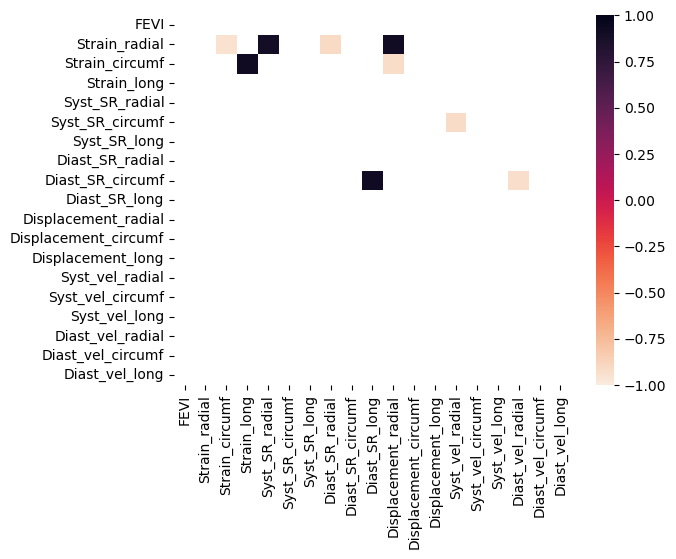

In [6]:
umbral=0.9

corr_matrix = X.corr()
corr_matrix_abs = corr_matrix.abs()

mask_corr = corr_matrix_abs > umbral

mask_upper_triangle = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)

mask = mask_corr & mask_upper_triangle

np.fill_diagonal(mask.values, False)
filtered_corr_matrix = corr_matrix[mask]

sns.heatmap(filtered_corr_matrix, vmin=-1, vmax=1, annot=False, cmap="rocket_r")
plt.show()

In [7]:
drop=corr_matrix_abs.where(mask)
to_drop = [col for col in drop.columns if any(drop[col] > umbral)]
to_drop

['Strain_circumf',
 'Strain_long',
 'Syst_SR_radial',
 'Diast_SR_radial',
 'Diast_SR_long',
 'Displacement_radial',
 'Syst_vel_radial',
 'Diast_vel_radial']

In [8]:
X_red=X.drop(columns=[to_drop[0]])
X_red.columns

Index(['FEVI', 'Strain_radial', 'Strain_long', 'Syst_SR_radial',
       'Syst_SR_circumf', 'Syst_SR_long', 'Diast_SR_radial',
       'Diast_SR_circumf', 'Diast_SR_long', 'Displacement_radial',
       'Displacement_circumf', 'Displacement_long', 'Syst_vel_radial',
       'Syst_vel_circumf', 'Syst_vel_long', 'Diast_vel_radial',
       'Diast_vel_circumf', 'Diast_vel_long'],
      dtype='object')

### Mutual Info:

In [9]:
from sklearn.metrics import mutual_info_score
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(X, y)

Text(0.5, 1.0, 'Mutual information between predictors and target')

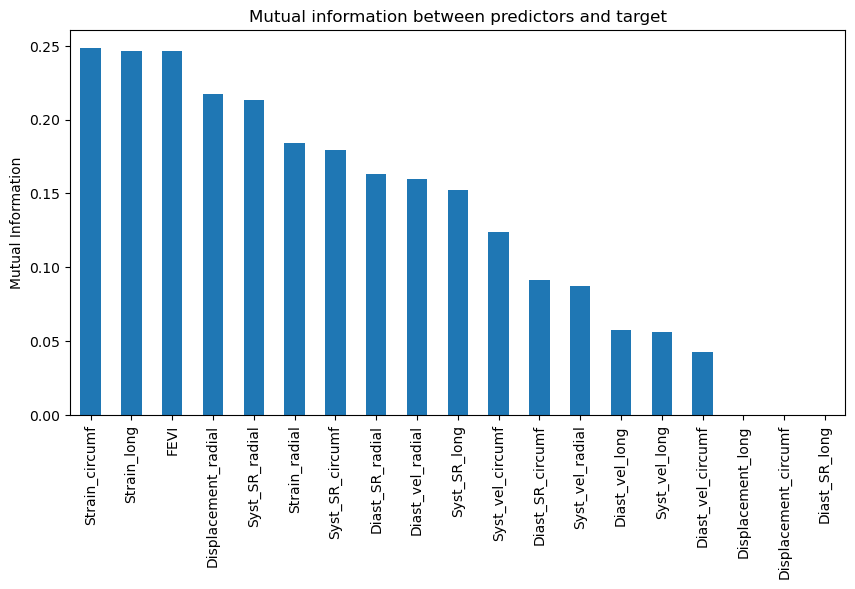

In [10]:
mi = pd.Series(mi)
mi.index = X.columns
mi.sort_values(ascending=False).plot.bar(figsize=(10, 5))
plt.ylabel('Mutual Information')
plt.title("Mutual information between predictors and target")

In [11]:
from sklearn.feature_selection import SelectKBest

num_var=10
sel = SelectKBest(mutual_info_classif, k=num_var).fit(X, y)

X_red_array = sel.transform(X)

selected_features = X.columns[sel.get_support()]

X_red = pd.DataFrame(X_red_array, columns=selected_features)

X_red.columns

Index(['FEVI', 'Strain_radial', 'Strain_circumf', 'Strain_long',
       'Syst_SR_radial', 'Syst_SR_circumf', 'Syst_SR_long', 'Diast_SR_radial',
       'Displacement_radial', 'Diast_vel_radial'],
      dtype='object')

### Solo Strain:

In [12]:
X_red = X[["Strain_radial","Strain_circumf","Strain_long"]]
X_red.columns

Index(['Strain_radial', 'Strain_circumf', 'Strain_long'], dtype='object')

# Let's create a circuit of maximum entanglement to extract quantum information:

In [13]:
# Separate X_test and X_train:
X_train, X_test, y_train, y_test = train_test_split(X_red, y, test_size=0.25, random_state=42)

# CZ circuit:

In [14]:
n_qubits = 10

dev = qml.device("default.qubit", wires=n_qubits)
@qml.qnode(dev)
def input_qnode(inputs): # , weights
    """ Quantum kernel as a first layer used to encode the data."""
    
    qml.AngleEmbedding(inputs, wires=range(n_qubits))
    for i in range(n_qubits-1):
        qml.CZ([i,i+1])
        
    for i in range(n_qubits):
        qml.RY(np.pi/3, i)
    
    #qml.BasicEntanglerLayers(weights, wires=range(n_qubits))
    return [qml.expval(qml.PauliX(wires=i)) for i in range(n_qubits)]

#n_layers = 1
#weight_shapes = {"weights": (n_layers, 1)}

In [15]:
# let's standarize the data from 0 to pi:

In [16]:
X_train = np.array(X_train)
X_test = np.array(X_test)

In [17]:
# Create a StandardScaler object
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

# 0 to np.pi
X_train_scaled = (X_train_scaled - X_train_scaled.min()) / (X_train_scaled.max() - X_train_scaled.min()) * np.pi
X_test_scaled = (X_test_scaled - X_test_scaled.min()) / (X_test_scaled.max() - X_test_scaled.min()) * np.pi

In [18]:
q_X_train = np.array([input_qnode(x) for x in X_train_scaled])
q_X_test = np.array([input_qnode(x) for x in X_test_scaled])

In [19]:
# Let's try different models:

### SVM:

#### Quantum:

In [20]:
import scipy

sigma_mean = np.mean(scipy.spatial.distance.pdist(q_X_train))
gamma_mean = 1/2/sigma_mean**2
param_grid = [{
    'C': [109, 110, 111],
    'gamma': np.logspace(np.log10(gamma_mean*0.1), np.log10(gamma_mean*10), 20),
    'kernel': ['rbf','linear']
}]

svc_model = GridSearchCV(SVC(probability=True), param_grid=param_grid, cv=5, verbose=1, n_jobs=2)

# fit model
svc_model.fit(q_X_train, y_train)
print(svc_model.best_score_)
print(svc_model.best_params_)

Fitting 5 folds for each of 120 candidates, totalling 600 fits
0.7055555555555555
{'C': 109, 'gamma': 0.08365931222027527, 'kernel': 'rbf'}


In [21]:
# train
y_preds_proba0 = svc_model.predict_proba(q_X_train)
y_preds0 = svc_model.predict(q_X_train)
auc0 = roc_auc_score(y_train, y_preds_proba0[:, 1])
acc0 = accuracy_score(y_train, y_preds0)
print("AUC train: ", auc0, '\nAccuracy train: ', acc0)

# validation
y_preds_proba = svc_model.predict_proba(q_X_test)
y_preds = svc_model.predict(q_X_test)

auc = roc_auc_score(y_test, y_preds_proba[:, 1])
acc = accuracy_score(y_test, y_preds)
print("AUC test: ", auc, '\nAccuracy test: ', acc)

AUC train:  0.84 
Accuracy train:  0.8181818181818182
AUC test:  0.8863636363636364 
Accuracy test:  0.8666666666666667


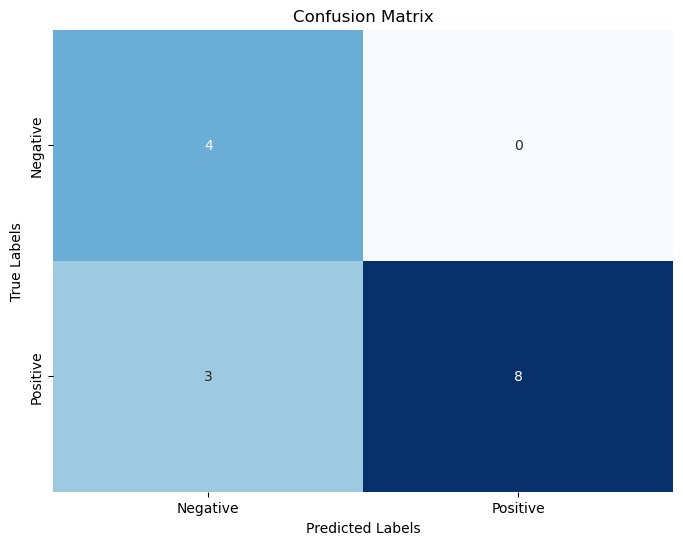

In [22]:
conf_matrix = confusion_matrix(y_test, np.round(y_preds_proba[:, 1]))

# Visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

#### Normal:

In [23]:
sigma_mean = np.mean(scipy.spatial.distance.pdist(X_train))
gamma_mean = 1/2/sigma_mean**2
param_grid = [{
    'C': [109, 110, 111],
    'gamma': np.logspace(np.log10(gamma_mean*0.1), np.log10(gamma_mean*10), 20),
    'kernel': ['rbf','linear']
}]

svc_model = GridSearchCV(SVC(probability=True), param_grid=param_grid, cv=5, verbose=1, n_jobs=2)

# fit model
svc_model.fit(X_train, y_train)
print(svc_model.best_score_)
print(svc_model.best_params_)

Fitting 5 folds for each of 120 candidates, totalling 600 fits
0.7055555555555555
{'C': 109, 'gamma': 0.0002051482860341553, 'kernel': 'rbf'}


In [24]:
# train
y_preds_proba0 = svc_model.predict_proba(X_train)
y_preds0 = svc_model.predict(X_train)
auc0 = roc_auc_score(y_train, y_preds_proba0[:, 1])
acc0 = accuracy_score(y_train, y_preds0)
print("AUC train: ", auc0, '\nAccuracy train: ', acc0)

# validation
y_preds_proba = svc_model.predict_proba(X_test)
y_preds = svc_model.predict(X_test)

auc = roc_auc_score(y_test, y_preds_proba[:, 1])
acc = accuracy_score(y_test, y_preds)
print("AUC test: ", auc, '\nAccuracy test: ', acc)

AUC train:  0.8326315789473684 
Accuracy train:  0.7727272727272727
AUC test:  0.9090909090909091 
Accuracy test:  0.7333333333333333


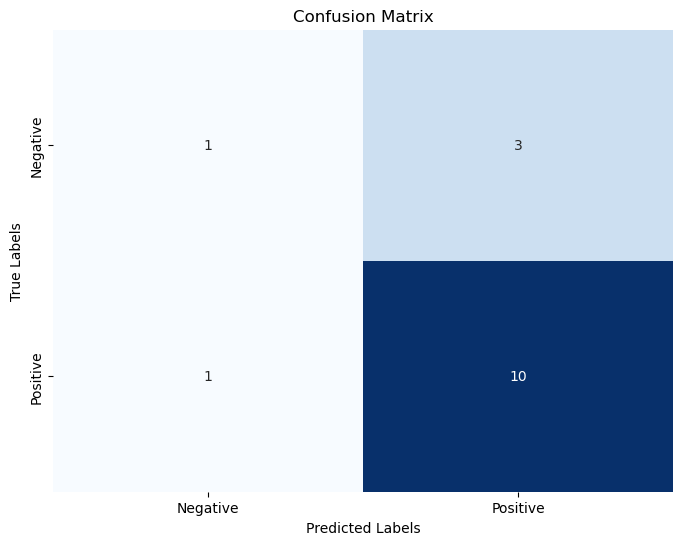

In [25]:
conf_matrix = confusion_matrix(y_test, np.round(y_preds_proba[:, 1]))

# Visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# CNN:

#### Quantum:

In [26]:
# Let's create a new model for quantum images:
def model(learning_rate = 0.001, n_qubits = n_qubits):
    """Initializes and returns a custom Keras model
    which is ready to be trained."""
    model = keras.models.Sequential([
        keras.layers.Dense(n_qubits, activation="relu"),
        keras.layers.Dropout(.4),
        keras.layers.Dense(n_qubits, activation="relu"),
        keras.layers.Dropout(.4),
        keras.layers.Dense(4, activation="relu"),
        keras.layers.Dense(2, activation="softmax"),
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [27]:
q_model = model(learning_rate = 0.0001, n_qubits = n_qubits)

q_history = q_model.fit(
    q_X_train,
    y_train,
    batch_size=2,
    epochs=500,
    verbose=1,
)

Epoch 1/500


2024-07-03 10:44:43.393141: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 689 MB memory:  -> device: 0, name: NVIDIA A16, pci bus id: 0000:85:00.0, compute capability: 8.6
2024-07-03 10:44:43.395515: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13104 MB memory:  -> device: 1, name: NVIDIA A16, pci bus id: 0000:86:00.0, compute capability: 8.6
2024-07-03 10:44:43.397703: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 13104 MB memory:  -> device: 2, name: NVIDIA A16, pci bus id: 0000:87:00.0, compute capability: 8.6
2024-07-03 10:44:43.399939: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 13104 MB memory:  -> device: 3, name: NVIDIA A16, pci bus id: 0000:88:00.0, compute capability: 8.6
20

22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.4442 - loss: 1.2660     
Epoch 2/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 847us/step - accuracy: 0.4733 - loss: 1.0782
Epoch 3/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 865us/step - accuracy: 0.4069 - loss: 0.8966   
Epoch 4/500


I0000 00:00:1720003487.003918   31768 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 990us/step - accuracy: 0.3511 - loss: 1.0741
Epoch 5/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 987us/step - accuracy: 0.4691 - loss: 0.9795   
Epoch 6/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4966 - loss: 1.0315 
Epoch 7/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2209 - loss: 1.1357     
Epoch 8/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3941 - loss: 1.0364     
Epoch 9/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7328 - loss: 0.6823 
Epoch 10/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4152 - loss: 0.7837 
Epoch 11/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4632 - loss: 0.9574 
Epoch 12/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5925 - loss: 0.8228 
Epoch 13/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3340 - loss: 0.9061 
Epoch 14/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 901us/step - accuracy: 0.3695 - loss: 0.8433
Epoch 15/500
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 974u

In [28]:
q_predictions = q_model.predict(q_X_test) # qunatum pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step


In [29]:
fprq, tprq, thresholdq = roc_curve(y_test, q_predictions[:,1])

# AUC:
auc = roc_auc_score(y_test, q_predictions[:,1])  

print("AUC:", auc)

# F1_score and recall:
f1 = f1_score(y_test, np.round(q_predictions[:,1]))

print('F1_Score:', f1)

# ACCURACY:
acc = accuracy_score(y_test, np.round(q_predictions[:,1]))
print('ACC:', acc)

AUC: 0.9204545454545454
F1_Score: 0.846153846153846
ACC: 0.7333333333333333


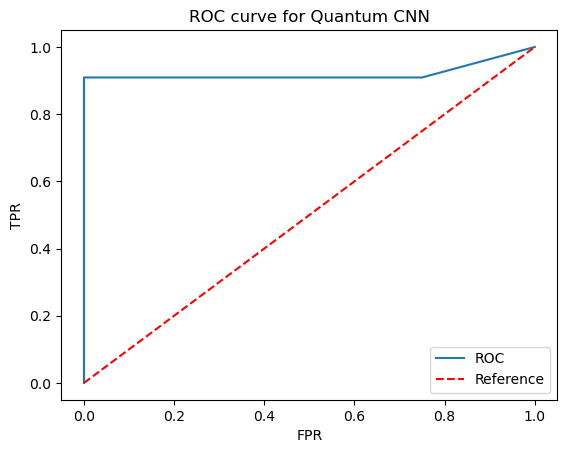

In [30]:
# Trazar la curva ROC
plt.plot(fprq, tprq, label='ROC')
plt.plot([0, 1], [0, 1], 'r--', label='Reference')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC curve for Quantum CNN')
plt.legend()
plt.show()

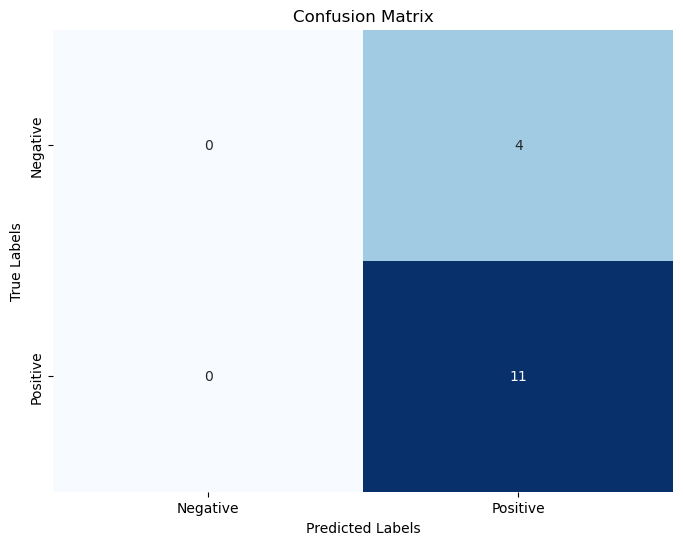

In [31]:
# Calcular la matriz de confusión
conf_matrix = confusion_matrix(y_test, np.round(q_predictions[:, 1]))

# Visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

#### Normal:

In [32]:
n_model = model(learning_rate = 0.0001, n_qubits = n_qubits)

n_history = n_model.fit(
    X_train,
    y_train,
    batch_size=2,
    epochs=150,
    verbose=0,
)

In [33]:
n_predictions = n_model.predict(X_test) # qunatum pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step


In [34]:
fprq, tprq, thresholdq = roc_curve(y_test, n_predictions[:,1])

# AUC:
auc = roc_auc_score(y_test, n_predictions[:,1])  

print("AUC:", auc)

# F1_score and recall:
f1 = f1_score(y_test, np.round(n_predictions[:,1]))

print('F1_Score:', f1)

# ACCURACY:
acc = accuracy_score(y_test, np.round(n_predictions[:,1]))
print('ACC:', acc)

AUC: 0.5
F1_Score: 0.0
ACC: 0.26666666666666666


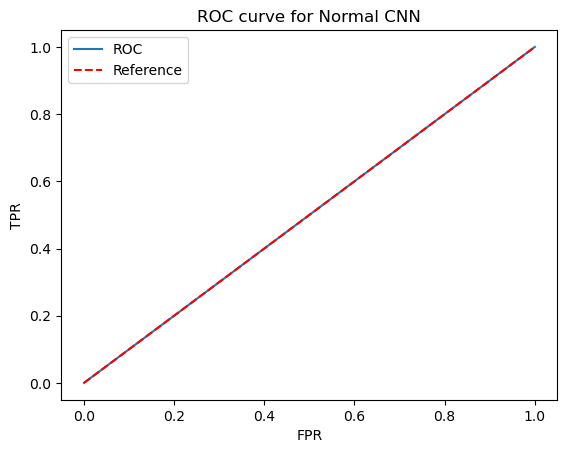

In [35]:
# Trazar la curva ROC
plt.plot(fprq, tprq, label='ROC')
plt.plot([0, 1], [0, 1], 'r--', label='Reference')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC curve for Normal CNN')
plt.legend()
plt.show()

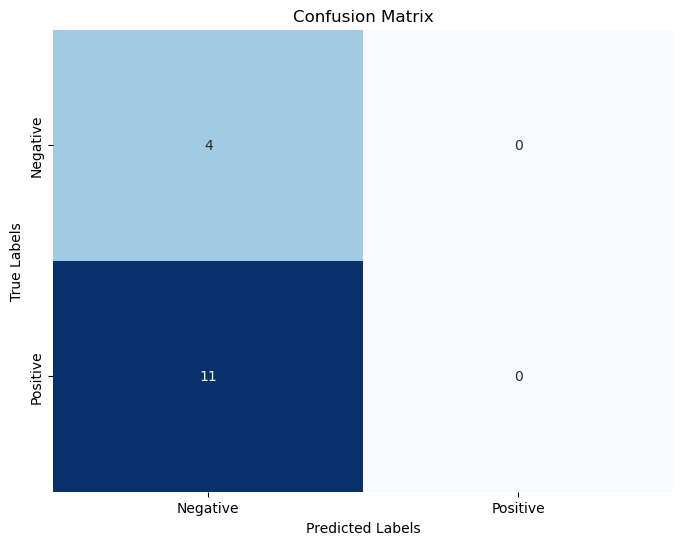

In [36]:
# Calcular la matriz de confusión
conf_matrix = confusion_matrix(y_test, np.round(n_predictions[:, 1]))

# Visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# ----------------------------------------------------------------------------------------

# Let's try another circuit, a fully connected one:

In [37]:
n_qubits = 3
dev = qml.device("default.qubit", wires=n_qubits)
@qml.qnode(dev, interface="autograd")
def CNOT_circuit(params):
    for idx in range(n_qubits):
        #qml.Hadamard(wires=idx)
        qml.RY(params[idx], wires=idx)
    
    pairs = [(i,j) for i in range(n_qubits) for j in range(n_qubits) if i < j]
    for pair in pairs:
            qml.CNOT(wires=[pair[0], pair[1]])

    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

In [38]:
q_X_train_cnot = np.array([CNOT_circuit(x) for x in X_train_scaled])
q_X_test_cnot = np.array([CNOT_circuit(x) for x in X_test_scaled])

#### Quantum:

In [39]:
q_model = model(learning_rate = 0.0001, n_qubits = n_qubits)

q_history = q_model.fit(
    q_X_train_cnot,
    y_train,
    batch_size=2,
    epochs=100,
    verbose=0,
)

Epoch 578/1000
22/22 - 0s - loss: 0.5335 - accuracy: 0.7955 - 19ms/epoch - 842us/step
Epoch 579/1000
22/22 - 0s - loss: 0.4410 - accuracy: 0.7500 - 18ms/epoch - 837us/step
Epoch 580/1000
22/22 - 0s - loss: 0.4850 - accuracy: 0.7045 - 17ms/epoch - 790us/step
Epoch 581/1000
22/22 - 0s - loss: 0.5676 - accuracy: 0.6818 - 17ms/epoch - 793us/step
Epoch 582/1000
22/22 - 0s - loss: 0.4290 - accuracy: 0.7955 - 17ms/epoch - 780us/step
Epoch 583/1000
22/22 - 0s - loss: 0.5150 - accuracy: 0.7045 - 18ms/epoch - 805us/step
Epoch 584/1000
22/22 - 0s - loss: 0.4581 - accuracy: 0.7727 - 18ms/epoch - 802us/step
Epoch 585/1000
22/22 - 0s - loss: 0.5324 - accuracy: 0.7955 - 18ms/epoch - 799us/step
Epoch 586/1000
22/22 - 0s - loss: 0.5092 - accuracy: 0.6591 - 17ms/epoch - 795us/step
Epoch 587/1000
22/22 - 0s - loss: 0.5198 - accuracy: 0.7273 - 17ms/epoch - 785us/step
Epoch 588/1000
22/22 - 0s - loss: 0.4418 - accuracy: 0.7045 - 16ms/epoch - 741us/step
Epoch 589/1000
22/22 - 0s - loss: 0.4344 - accuracy: 0

Epoch 674/1000
22/22 - 0s - loss: 0.4390 - accuracy: 0.7955 - 15ms/epoch - 702us/step
Epoch 675/1000
22/22 - 0s - loss: 0.4301 - accuracy: 0.7273 - 15ms/epoch - 693us/step
Epoch 676/1000
22/22 - 0s - loss: 0.4296 - accuracy: 0.8636 - 16ms/epoch - 708us/step
Epoch 677/1000
22/22 - 0s - loss: 0.3826 - accuracy: 0.8864 - 16ms/epoch - 708us/step
Epoch 678/1000
22/22 - 0s - loss: 0.3908 - accuracy: 0.8636 - 16ms/epoch - 729us/step
Epoch 679/1000
22/22 - 0s - loss: 0.4061 - accuracy: 0.8409 - 17ms/epoch - 773us/step
Epoch 680/1000
22/22 - 0s - loss: 0.4247 - accuracy: 0.7500 - 15ms/epoch - 673us/step
Epoch 681/1000
22/22 - 0s - loss: 0.5177 - accuracy: 0.7500 - 15ms/epoch - 689us/step
Epoch 682/1000
22/22 - 0s - loss: 0.4808 - accuracy: 0.7727 - 15ms/epoch - 681us/step
Epoch 683/1000
22/22 - 0s - loss: 0.4714 - accuracy: 0.7955 - 15ms/epoch - 683us/step
Epoch 684/1000
22/22 - 0s - loss: 0.4271 - accuracy: 0.7955 - 15ms/epoch - 682us/step
Epoch 685/1000
22/22 - 0s - loss: 0.4255 - accuracy: 0

Epoch 770/1000
22/22 - 0s - loss: 0.4487 - accuracy: 0.7500 - 17ms/epoch - 768us/step
Epoch 771/1000
22/22 - 0s - loss: 0.3496 - accuracy: 0.8864 - 17ms/epoch - 767us/step
Epoch 772/1000
22/22 - 0s - loss: 0.4107 - accuracy: 0.8409 - 17ms/epoch - 789us/step
Epoch 773/1000
22/22 - 0s - loss: 0.3958 - accuracy: 0.8182 - 17ms/epoch - 759us/step
Epoch 774/1000
22/22 - 0s - loss: 0.4343 - accuracy: 0.7500 - 17ms/epoch - 768us/step
Epoch 775/1000
22/22 - 0s - loss: 0.4441 - accuracy: 0.8636 - 17ms/epoch - 772us/step
Epoch 776/1000
22/22 - 0s - loss: 0.4696 - accuracy: 0.7500 - 17ms/epoch - 760us/step
Epoch 777/1000
22/22 - 0s - loss: 0.3688 - accuracy: 0.8864 - 15ms/epoch - 703us/step
Epoch 778/1000
22/22 - 0s - loss: 0.4130 - accuracy: 0.8182 - 17ms/epoch - 756us/step
Epoch 779/1000
22/22 - 0s - loss: 0.3606 - accuracy: 0.8636 - 16ms/epoch - 726us/step
Epoch 780/1000
22/22 - 0s - loss: 0.4186 - accuracy: 0.8182 - 16ms/epoch - 740us/step
Epoch 781/1000
22/22 - 0s - loss: 0.5503 - accuracy: 0

Epoch 866/1000
22/22 - 0s - loss: 0.3641 - accuracy: 0.8636 - 17ms/epoch - 766us/step
Epoch 867/1000
22/22 - 0s - loss: 0.3869 - accuracy: 0.7500 - 17ms/epoch - 769us/step
Epoch 868/1000
22/22 - 0s - loss: 0.3742 - accuracy: 0.8864 - 17ms/epoch - 794us/step
Epoch 869/1000
22/22 - 0s - loss: 0.3861 - accuracy: 0.8409 - 17ms/epoch - 783us/step
Epoch 870/1000
22/22 - 0s - loss: 0.3450 - accuracy: 0.8636 - 17ms/epoch - 759us/step
Epoch 871/1000
22/22 - 0s - loss: 0.4042 - accuracy: 0.7955 - 17ms/epoch - 777us/step
Epoch 872/1000
22/22 - 0s - loss: 0.4667 - accuracy: 0.8864 - 17ms/epoch - 789us/step
Epoch 873/1000
22/22 - 0s - loss: 0.3405 - accuracy: 0.8636 - 17ms/epoch - 777us/step
Epoch 874/1000
22/22 - 0s - loss: 0.4129 - accuracy: 0.7727 - 18ms/epoch - 799us/step
Epoch 875/1000
22/22 - 0s - loss: 0.3771 - accuracy: 0.8864 - 17ms/epoch - 768us/step
Epoch 876/1000
22/22 - 0s - loss: 0.3604 - accuracy: 0.8409 - 17ms/epoch - 788us/step
Epoch 877/1000
22/22 - 0s - loss: 0.4255 - accuracy: 0

Epoch 962/1000
22/22 - 0s - loss: 0.4664 - accuracy: 0.7955 - 18ms/epoch - 814us/step
Epoch 963/1000
22/22 - 0s - loss: 0.3646 - accuracy: 0.8864 - 18ms/epoch - 799us/step
Epoch 964/1000
22/22 - 0s - loss: 0.3810 - accuracy: 0.8409 - 18ms/epoch - 811us/step
Epoch 965/1000
22/22 - 0s - loss: 0.3966 - accuracy: 0.7727 - 18ms/epoch - 806us/step
Epoch 966/1000
22/22 - 0s - loss: 0.4055 - accuracy: 0.8864 - 17ms/epoch - 793us/step
Epoch 967/1000
22/22 - 0s - loss: 0.3348 - accuracy: 0.8409 - 16ms/epoch - 726us/step
Epoch 968/1000
22/22 - 0s - loss: 0.4213 - accuracy: 0.9091 - 16ms/epoch - 734us/step
Epoch 969/1000
22/22 - 0s - loss: 0.4028 - accuracy: 0.8409 - 17ms/epoch - 770us/step
Epoch 970/1000
22/22 - 0s - loss: 0.3760 - accuracy: 0.8182 - 17ms/epoch - 754us/step
Epoch 971/1000
22/22 - 0s - loss: 0.3706 - accuracy: 0.7955 - 16ms/epoch - 743us/step
Epoch 972/1000
22/22 - 0s - loss: 0.3332 - accuracy: 0.8636 - 18ms/epoch - 812us/step
Epoch 973/1000
22/22 - 0s - loss: 0.4143 - accuracy: 0

In [40]:
q_predictions_cnot = q_model.predict(q_X_test_cnot) # qunatum pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step


In [41]:
fprq, tprq, thresholdq = roc_curve(y_test, q_predictions_cnot[:,1])

# AUC:
auc = roc_auc_score(y_test, np.round(q_predictions_cnot[:,1]))  

print("AUC:", auc)

# F1_score and recall:
f1 = f1_score(y_test, np.round(q_predictions_cnot[:,1]))

print('F1_Score:', f1)

# ACCURACY:
acc = accuracy_score(y_test, np.round(q_predictions_cnot[:,1]))
print('ACC:', acc)

AUC: 0.5
F1_Score: 0.846153846153846
ACC: 0.7333333333333333


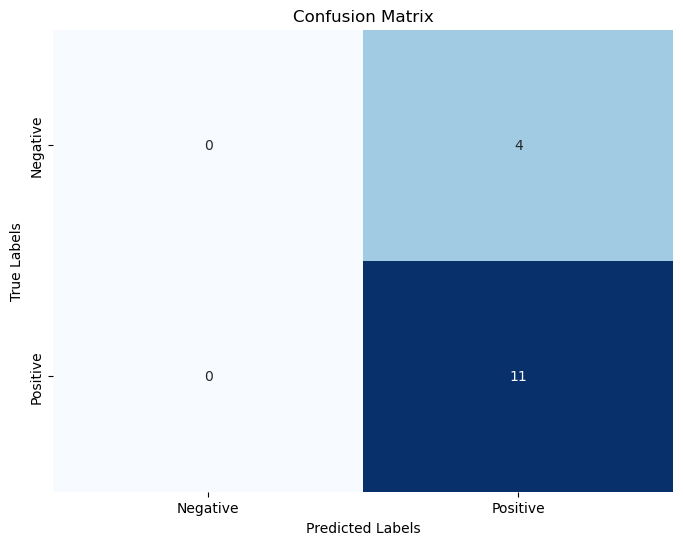

In [42]:
# Calcular la matriz de confusión
conf_matrix = confusion_matrix(y_test, np.round(q_predictions_cnot[:, 1]))

# Visualizar la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()